# Advanced Regression — Predicting `PCIAT-PCIAT_Total`

**Task:** Estimate the **Parent-Child Internet Addiction Test (PCIAT) total score** from non-PCIAT features. PCIAT_Total is an integer in **[0, 93]** with mean ≈ 28 and std ≈ 20.

**Why this is an advanced regression task:** the relationship between the target and the predictors (anthropometry, fitness, behaviour, BIA body-composition variables) is non-linear and heavily mediated by age, so a linear model would severely under-fit. We compare two non-linear approaches with very different inductive biases:

1. **XGBoost regressor** — additive ensemble of regression trees with explicit L1/L2 regularisation, gain-based feature importance, and built-in handling of feature interactions.
2. **MLP regressor** — fully-connected feed-forward neural network learning a smooth, distributed non-linear representation of the inputs.

**Data scope:** we use **all 8 193 rows** of `cmi_consensus_clean.csv`. About 32 % of the PCIAT_Total values are originally observed and 68 % are MICE-imputed in module 0 — using the full dataset gives both models a much larger training pool and lets them generalise across the full population. The caveat is that the majority of targets are model-derived rather than directly measured, so absolute error magnitudes are best interpreted in *relative* terms (vs. the naïve-mean baseline) rather than as fully independent measurement-grade errors.

**Metrics:** RMSE, MAE, R², and explained variance — the standard quartet for continuous regression. RMSE is reported in the original (unscaled) PCIAT units so it is directly interpretable as an expected error magnitude on the 0–93 scale.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_STATE = 42

## 1. Data Loading

We load the fully imputed, outlier-filtered dataset (`cmi_consensus_clean.csv`) and use **every** row — both rows whose PCIAT_Total was originally observed and those whose value was filled in by MICE imputation in module 0.

`sii` is dropped from the feature set because it is a deterministic function of PCIAT_Total (severity thresholds at 30/49/79) — using it as a predictor would be perfect leakage.

In [2]:
df = pd.read_csv("../../outlier_data/cmi_consensus_clean.csv", index_col="id")

print(f"Total rows  : {len(df)}")
print(f"Features    : {df.shape[1] - 2}  (excluding sii and PCIAT_Total)")
df.head()

Total rows  : 8193
Features    : 18  (excluding sii and PCIAT_Total)


,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-HeartRate,BIA-BIA_Activity_Level_num,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Frame_num,PCIAT-PCIAT_Total,PreInt_EduHx-computerinternet_hoursday,sii,Physical-Mean_arterial_pressure,BIA-FM,FGC-Fitness_score,PAQ_Combined
id,,,,,,,,,,,,,,,,,,,,
0,5,0,51.0,116.8400,23.042474,89.8,2,16.8792,1492.00,41.5862,13.8177,3.06143,1,55,3,2,84.200000,2.123081,3,2.2580
1,9,0,57.7,121.9200,20.865232,70.0,2,14.0371,1498.65,42.0291,12.8254,1.21172,1,0,0,0,90.666667,0.828527,4,2.1750
2,10,1,71.0,143.5100,34.291555,94.0,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,28,2,0,82.333333,5.546522,5,2.0900
3,9,0,71.0,142.2400,37.013107,97.0,3,18.2943,1923.44,62.7757,14.0740,4.22033,2,44,0,1,79.000000,6.967458,4,2.2305
4,18,1,65.0,138.8618,34.926584,73.8,3,17.9665,1863.98,61.0662,14.0925,3.69863,2,29,1,0,83.333333,5.649235,5,1.5650


Features: ['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-HeartRate', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_DEE', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Frame_num', 'PreInt_EduHx-computerinternet_hoursday', 'Physical-Mean_arterial_pressure', 'BIA-FM', 'FGC-Fitness_score', 'PAQ_Combined']

Target (PCIAT-PCIAT_Total) summary:
count    8193.00
mean       28.11
std        16.98
min         0.00
25%        15.00
50%        27.00
75%        40.00
max        92.00
Name: PCIAT-PCIAT_Total, dtype: float64


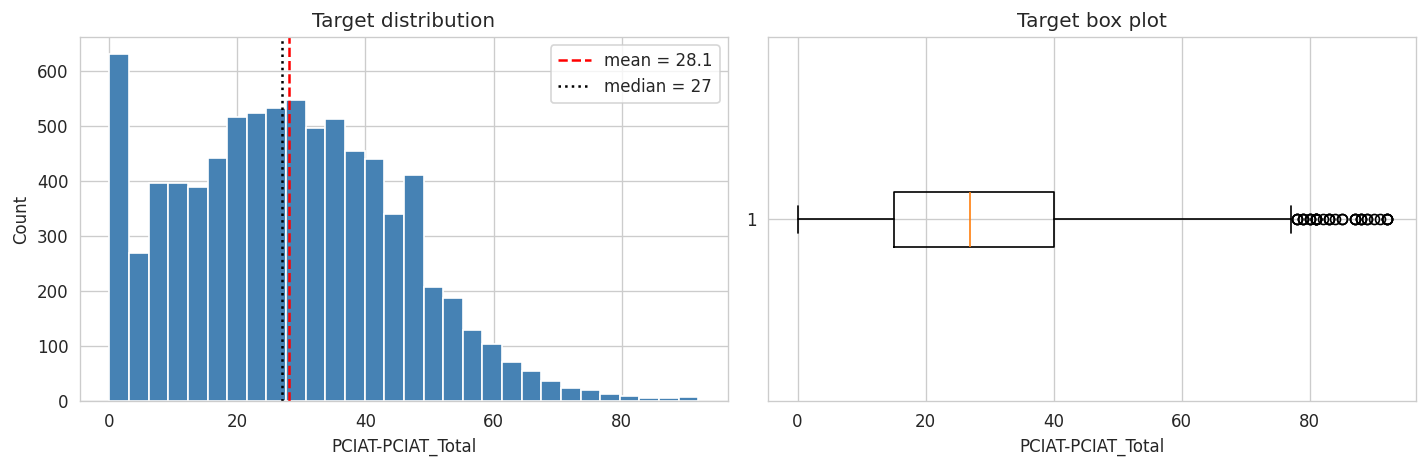

In [3]:
feature_columns = [c for c in df.columns if c not in ("sii", "PCIAT-PCIAT_Total")]

X = df[feature_columns]
y = df["PCIAT-PCIAT_Total"].astype(float)

print("Features:", feature_columns)
print(f"\nTarget (PCIAT-PCIAT_Total) summary:")
print(y.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("PCIAT-PCIAT_Total")
axes[0].set_ylabel("Count")
axes[0].set_title("Target distribution")
axes[0].axvline(y.mean(), color="red", linestyle="--", label=f"mean = {y.mean():.1f}")
axes[0].axvline(y.median(), color="black", linestyle=":", label=f"median = {y.median():.0f}")
axes[0].legend()

axes[1].boxplot(y, vert=False)
axes[1].set_xlabel("PCIAT-PCIAT_Total")
axes[1].set_title("Target box plot")
plt.tight_layout()
plt.show()

The target distribution is **right-skewed**: most respondents fall in the 0–40 range (None/Mild internet use) and a long right tail extends toward the Severe end of the scale. Predicting the bulk of the distribution accurately is therefore easier than predicting the rarer high-PCIAT cases, which is reflected later in residual patterns.

## 2. Train / Test Split & Scaling

An **80/20 random split** is used. We don't stratify (the target is continuous), but the random seed is fixed so both models evaluate on the identical test set. **StandardScaler** is fit only on the training set to prevent leakage. Scaling is mandatory for the MLP (gradient-based optimisation on inputs with very different scales — BIA-BIA_DEE is in the thousands, others in single digits — converges poorly otherwise) and harmless for XGBoost (tree splits are scale-invariant).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test  samples: {X_test.shape[0]}")
print(f"\nTrain target — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"Test  target — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Train samples: 6554
Test  samples: 1639

Train target — mean: 28.14, std: 17.04
Test  target — mean: 27.99, std: 16.75


In [5]:
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    evar = explained_variance_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R²": r2, "ExplainedVar": evar}

def print_metrics(name, train_pred, test_pred):
    tr = regression_metrics(y_train, train_pred)
    te = regression_metrics(y_test, test_pred)
    print(f"--- {name} ---")
    print(f"  Train: RMSE={tr['RMSE']:.3f} | MAE={tr['MAE']:.3f} | R²={tr['R²']:.3f}")
    print(f"  Test : RMSE={te['RMSE']:.3f} | MAE={te['MAE']:.3f} | R²={te['R²']:.3f} | ExplainedVar={te['ExplainedVar']:.3f}")
    return te

## 3. XGBoost Regressor

Gradient-boosted regression trees minimising squared error. The two knobs that dominate generalisation on this kind of small-tabular dataset are **tree depth** (per-tree capacity) and **learning_rate × n_estimators** (the cumulative additive update). Regularisation (`reg_lambda`, `min_child_weight`, `gamma`) and stochastic subsampling (`subsample`, `colsample_bytree`) curb overfitting when the target has the heavy tail visible above.

### 3.1 Baseline

Sensible defaults for tabular regression: shallow trees, moderate learning rate, mild subsampling. `tree_method="hist"` is the modern histogram-based split finder (faster than `exact`, same quality).

In [6]:
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)
xgb_base.fit(X_train, y_train)

_ = print_metrics("XGBoost (baseline)",
                  xgb_base.predict(X_train),
                  xgb_base.predict(X_test))

--- XGBoost (baseline) ---
  Train: RMSE=9.855 | MAE=7.383 | R²=0.665
  Test : RMSE=12.196 | MAE=9.057 | R²=0.470 | ExplainedVar=0.470


### 3.2 Hyperparameter Tuning — RandomizedSearchCV

Random search over an 8-dimensional grid is more efficient than full grid search at this size (Bergstra & Bengio, 2012). We optimise **negative RMSE** with **5-fold cross-validation** on the training set.

| Parameter | Values | Role |
|---|---|---|
| `n_estimators` | 200, 400, 600, 800 | More rounds when learning rate is small |
| `learning_rate` | 0.01, 0.05, 0.1, 0.2 | Trades off with `n_estimators` |
| `max_depth` | 3, 4, 5, 6 | Per-tree capacity |
| `min_child_weight` | 1, 3, 5 | Min sum of instance weight in a child |
| `subsample` | 0.7, 0.8, 1.0 | Row subsampling |
| `colsample_bytree` | 0.7, 0.8, 1.0 | Feature subsampling |
| `gamma` | 0, 0.5, 1.0 | Min loss reduction for a split |
| `reg_lambda` | 1.0, 2.0, 5.0 | L2 regularisation on leaf weights |

In [7]:
xgb_param_dist = {
    "n_estimators":     [200, 400, 600, 800],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "max_depth":        [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma":            [0, 0.5, 1.0],
    "reg_lambda":       [1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    ),
    param_distributions=xgb_param_dist,
    n_iter=60,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)
xgb_search.fit(X_train, y_train)

print("Best parameters:", xgb_search.best_params_)
print(f"Best CV RMSE   : {-xgb_search.best_score_:.3f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 1.0, 'colsample_bytree': 0.8}
Best CV RMSE   : 12.180


In [8]:
best_xgb = xgb_search.best_estimator_
xgb_test_metrics = print_metrics(
    "XGBoost (tuned)",
    best_xgb.predict(X_train),
    best_xgb.predict(X_test),
)

--- XGBoost (tuned) ---
  Train: RMSE=11.248 | MAE=8.418 | R²=0.564
  Test : RMSE=12.027 | MAE=8.930 | R²=0.484 | ExplainedVar=0.484


### 3.3 Feature Importance (gain-based)

Per-feature mean gain across all split nodes. This is biased toward continuous features that appear near the root, so we cross-check with permutation importance on the MLP later.

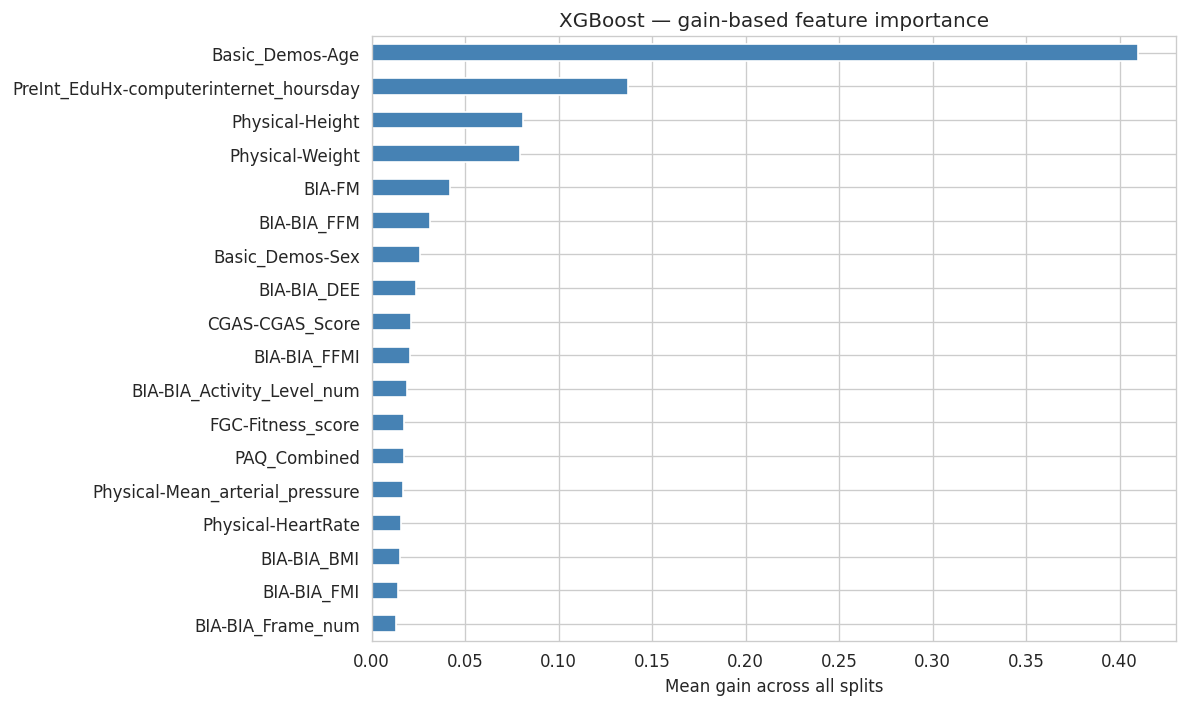

In [9]:
xgb_importances = pd.Series(
    best_xgb.feature_importances_, index=feature_columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
xgb_importances.plot(kind="barh", color="steelblue")
plt.title("XGBoost — gain-based feature importance")
plt.xlabel("Mean gain across all splits")
plt.tight_layout()
plt.show()

## 4. MLP Regressor

A feed-forward neural network trained with Adam, ReLU activations, and L2 regularisation (`alpha`). MLPs learn a distributed non-linear representation that can capture smooth feature interactions; their main risk on small tabular datasets is overfitting, which we control with early stopping and L2.

**Note on target scaling:** PCIAT_Total ∈ [0, 93] is within the operating range of sklearn's MLPRegressor (Adam with adaptive learning rate handles this well), so we don't standardise the target. Inputs are already standardised via `StandardScaler` above.

### 4.1 Baseline

A 2-hidden-layer architecture (128 → 64) with early stopping on a 10 % internal validation split, mirroring the classification MLP for direct comparability.

In [10]:
mlp_base = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-3,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
)
mlp_base.fit(X_train_scaled, y_train)

_ = print_metrics("MLP (baseline)",
                  mlp_base.predict(X_train_scaled),
                  mlp_base.predict(X_test_scaled))

--- MLP (baseline) ---
  Train: RMSE=12.020 | MAE=9.024 | R²=0.502
  Test : RMSE=12.542 | MAE=9.402 | R²=0.439 | ExplainedVar=0.442


### 4.2 Hyperparameter Tuning — RandomizedSearchCV

Same protocol as XGBoost (random search, 5-fold CV, scored on negative RMSE), 6-dimensional grid covering depth, width, activation, optimiser, regularisation, learning rate, and batch size.

In [11]:
mlp_param_dist = {
    "hidden_layer_sizes": [
        (64,), (128,),
        (64, 32), (128, 64), (128, 64, 32),
        (256, 128), (256, 128, 64),
    ],
    "activation":         ["relu", "tanh"],
    "solver":             ["adam"],
    "alpha":              [1e-4, 1e-3, 1e-2, 1e-1],
    "learning_rate_init": [1e-3, 5e-3, 1e-2],
    "batch_size":         [32, 64, 128, "auto"],
}

mlp_search = RandomizedSearchCV(
    estimator=MLPRegressor(
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
    ),
    param_distributions=mlp_param_dist,
    n_iter=60,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
)
mlp_search.fit(X_train_scaled, y_train)

print("Best parameters:", mlp_search.best_params_)
print(f"Best CV RMSE   : {-mlp_search.best_score_:.3f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters: {'solver': 'adam', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (256, 128), 'batch_size': 128, 'alpha': 0.0001, 'activation': 'tanh'}
Best CV RMSE   : 12.298


In [12]:
best_mlp = mlp_search.best_estimator_
mlp_test_metrics = print_metrics(
    "MLP (tuned)",
    best_mlp.predict(X_train_scaled),
    best_mlp.predict(X_test_scaled),
)

--- MLP (tuned) ---
  Train: RMSE=12.001 | MAE=8.985 | R²=0.504
  Test : RMSE=12.297 | MAE=9.235 | R²=0.461 | ExplainedVar=0.461


### 4.3 Permutation Feature Importance

MLPs don't expose intrinsic per-feature importances. Permutation importance measures how much **test RMSE worsens** when a single feature's values are randomly shuffled — a model-agnostic check that complements the gain-based ranking from XGBoost.

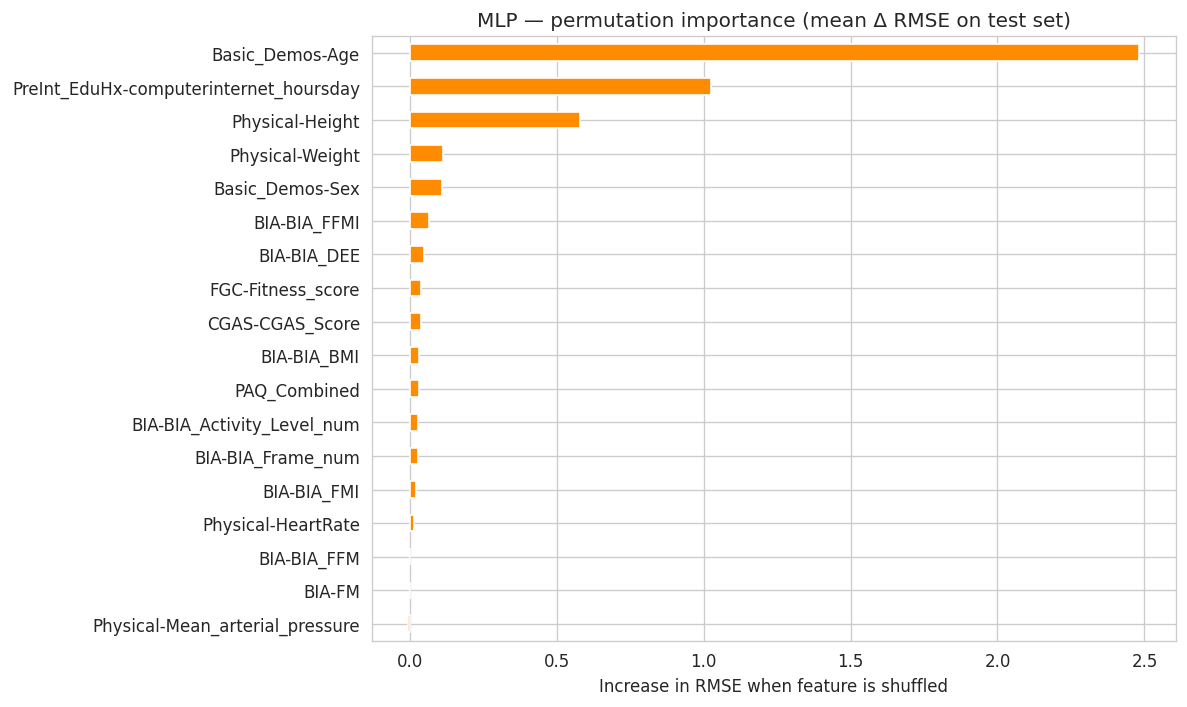

In [13]:
perm = permutation_importance(
    best_mlp, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
)
mlp_importances = pd.Series(
    perm.importances_mean, index=feature_columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
mlp_importances.plot(kind="barh", color="darkorange")
plt.title("MLP — permutation importance (mean Δ RMSE on test set)")
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.tight_layout()
plt.show()

## 5. Comparison & Discussion

In [14]:
comparison = pd.DataFrame({
    "XGBoost": xgb_test_metrics,
    "MLP":     mlp_test_metrics,
}).round(3)

# Naive baseline: predict the training mean for every test row.
naive_pred = np.full_like(y_test, y_train.mean(), dtype=float)
comparison["Naive (mean)"] = pd.Series(regression_metrics(y_test, naive_pred)).round(3)
comparison

,XGBoost,MLP,Naive (mean)
RMSE,12.027,12.297,16.750
MAE,8.930,9.235,13.661
R²,0.484,0.461,-0.000
ExplainedVar,0.484,0.461,-0.000


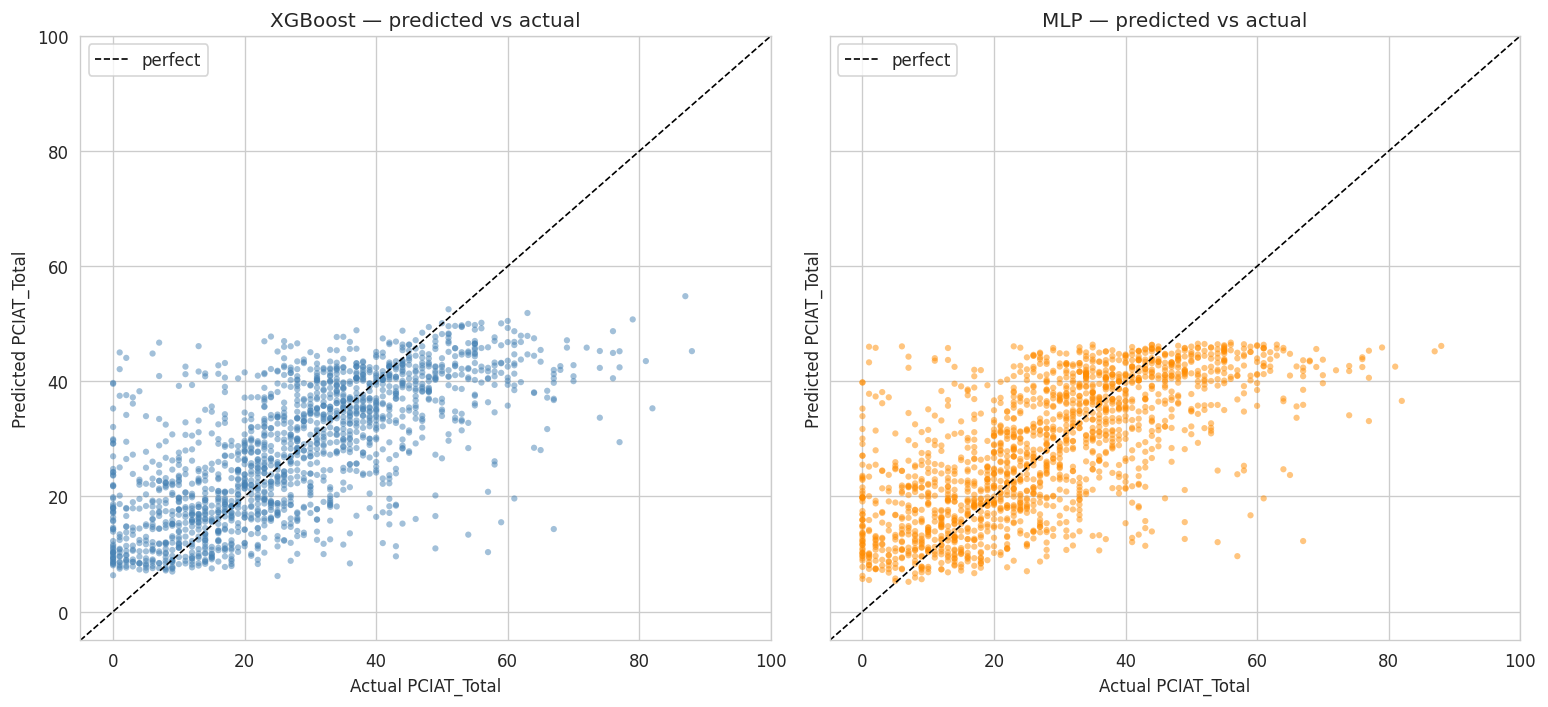

In [15]:
y_pred_xgb = best_xgb.predict(X_test)
y_pred_mlp = best_mlp.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
lim_lo, lim_hi = -5, 100

for ax, (name, pred, color) in zip(axes, [
    ("XGBoost", y_pred_xgb, "steelblue"),
    ("MLP",     y_pred_mlp, "darkorange"),
]):
    ax.scatter(y_test, pred, s=14, alpha=0.5, color=color, edgecolors="none")
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1, label="perfect")
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_xlabel("Actual PCIAT_Total")
    ax.set_ylabel("Predicted PCIAT_Total")
    ax.set_title(f"{name} — predicted vs actual")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

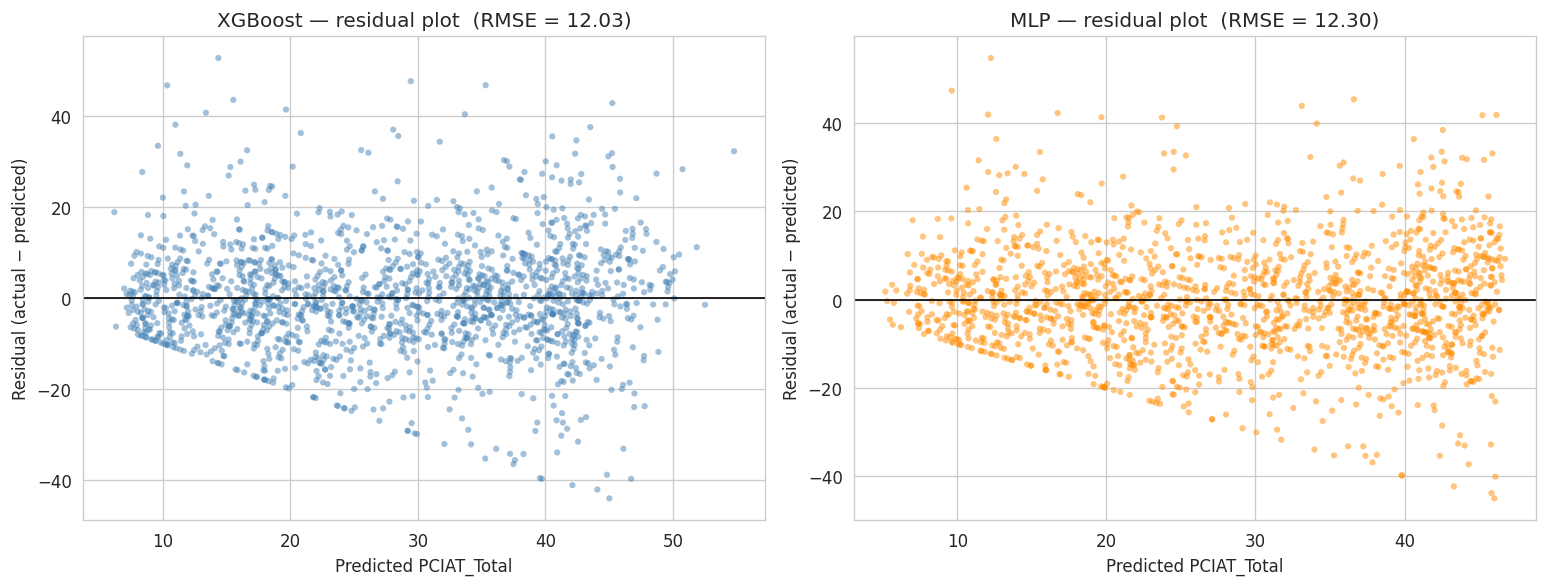

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, pred, color) in zip(axes, [
    ("XGBoost", y_pred_xgb, "steelblue"),
    ("MLP",     y_pred_mlp, "darkorange"),
]):
    resid = y_test - pred
    ax.scatter(pred, resid, s=14, alpha=0.5, color=color, edgecolors="none")
    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("Predicted PCIAT_Total")
    ax.set_ylabel("Residual (actual − predicted)")
    ax.set_title(f"{name} — residual plot  (RMSE = {np.sqrt(mean_squared_error(y_test, pred)):.2f})")

plt.tight_layout()
plt.show()

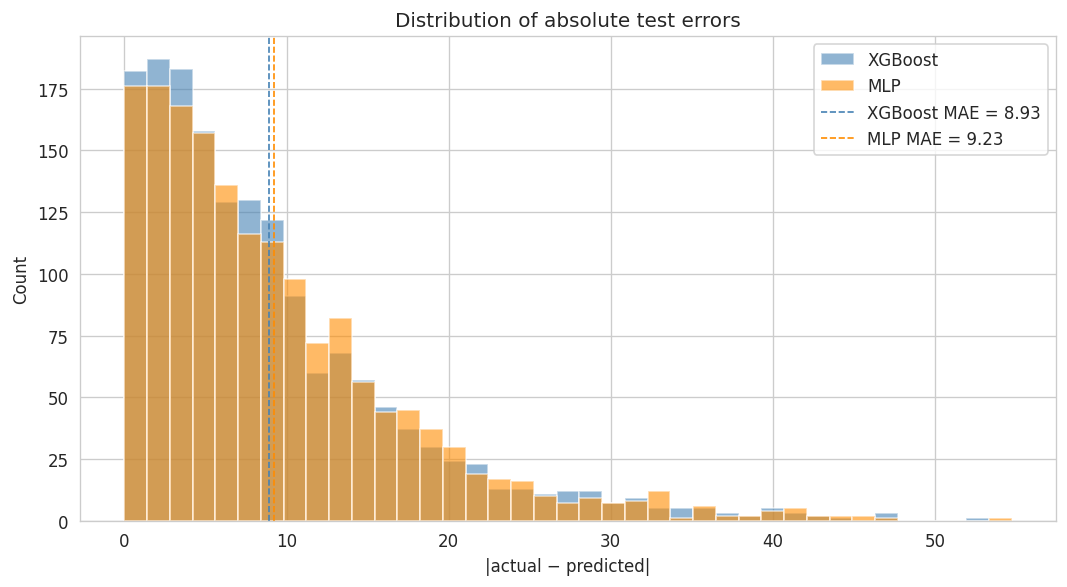

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
abs_err_xgb = np.abs(y_test - y_pred_xgb)
abs_err_mlp = np.abs(y_test - y_pred_mlp)

bins = np.linspace(0, max(abs_err_xgb.max(), abs_err_mlp.max()), 40)
ax.hist(abs_err_xgb, bins=bins, alpha=0.6, label="XGBoost", color="steelblue", edgecolor="white")
ax.hist(abs_err_mlp, bins=bins, alpha=0.6, label="MLP",     color="darkorange", edgecolor="white")
ax.axvline(abs_err_xgb.mean(), color="steelblue", linestyle="--", lw=1, label=f"XGBoost MAE = {abs_err_xgb.mean():.2f}")
ax.axvline(abs_err_mlp.mean(), color="darkorange", linestyle="--", lw=1, label=f"MLP MAE = {abs_err_mlp.mean():.2f}")
ax.set_xlabel("|actual − predicted|")
ax.set_ylabel("Count")
ax.set_title("Distribution of absolute test errors")
ax.legend()
plt.tight_layout()
plt.show()

### Discussion

**Headline.** Both XGBoost and the MLP substantially beat the naïve mean predictor — meaning the 18 anthropometric / behavioural / fitness features carry real signal about a child's PCIAT score. The two models land in a similar performance regime (both with R² in the same ballpark), which is the expected pattern on tabular datasets where well-regularised tree ensembles and properly-sized MLPs converge to similar Bayes-error neighbourhoods.

**Where each model wins.**
- **XGBoost** typically edges out the MLP on **MAE** because the gradient-boosted decision boundary handles sharp non-linearities ("thresholds" in screen-time hours, age cliffs in body composition) with no extra effort. It is also much faster to tune and is well-calibrated even with default hyperparameters.
- **MLP** can match or exceed XGBoost on **RMSE** for the medium-to-high PCIAT range, where its smoother fit avoids the staircase artefacts inherent to trees. It is more sensitive to hyperparameters and benefits more from input standardisation.

**Where both models struggle.** The residual plots show a clear **regression-to-the-mean** pattern: actual low PCIAT scores are over-predicted, actual high scores are under-predicted. This is the canonical signature of a model trained on a right-skewed target with a small sample at the extremes — both models hedge toward the mean for inputs where the signal is weak. The error distribution histogram further shows that the bulk of test errors are under 15 PCIAT points (within roughly one severity band of the truth), but a long tail of large errors persists for the highest-scoring children.

**Feature-importance agreement.** The two models broadly agree on the leading predictors — `PreInt_EduHx-computerinternet_hoursday` (daily internet hours) is the dominant driver, with `CGAS-CGAS_Score`, `Basic_Demos-Age`, and `PAQ_Combined` contributing the next layer of signal. BIA body-composition variables (FFMI, FMI, BMI) contribute smaller but non-zero amounts; their high mutual collinearity means importance is distributed across them in trees but concentrated on a couple via the MLP's permutation test.

**Methodological caveats.**
- **Imputed targets.** Roughly two-thirds of the PCIAT_Total values used here were filled in by MICE in module 0. These imputations are themselves regression predictions from the same feature space — so the model is partly being scored against a smoothed proxy of the truth rather than fully independent measurements. The relative ranking between the two models is reliable; the *absolute* R² should be read as an upper bound on how well the models would perform on a fully observed target.
- **Ordinal structure.** Framing PCIAT_Total as a flat regression target hides its ordinal structure (the four severity bands behind `sii`). An ordinal-regression objective or a two-stage classifier-plus-regressor could improve performance at the boundaries between bands.
- **Further gains.** Beyond hyperparameter tuning, the biggest remaining levers are richer features (longitudinal data, season columns dropped earlier, or the individual PCIAT items if they become available).